In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
dataset = pd.read_csv("D:/M.Tech/Semester 1/Foundations of Data Engineering/water_potability.csv")

In [4]:
df = dataset.drop(columns=["Potability"])

In [5]:
mean_values = df.mean()
print("Mean values:\n", mean_values)

Mean values:
 ph                     7.080795
Hardness             196.369496
Solids             22014.092526
Chloramines            7.122277
Sulfate              333.775777
Conductivity         426.205111
Organic_carbon        14.284970
Trihalomethanes       66.396293
Turbidity              3.966786
dtype: float64


In [6]:
median_values = df.median()
print("Median values:\n", median_values)

Median values:
 ph                     7.080795
Hardness             196.967627
Solids             20927.833607
Chloramines            7.130299
Sulfate              333.775777
Conductivity         421.884968
Organic_carbon        14.218338
Trihalomethanes       66.396293
Turbidity              3.955028
dtype: float64


In [7]:
mode_values = df.mode().iloc[0]
print("Mode values:\n", mode_values)

Mode values:
 ph                   7.080795
Hardness            47.432000
Solids             320.942611
Chloramines          0.352000
Sulfate            333.775777
Conductivity       181.483754
Organic_carbon       2.200000
Trihalomethanes     66.396293
Turbidity            1.450000
Name: 0, dtype: float64


In [8]:
std_values = df.std()
print("Standard Deviation:\n", std_values)

Standard Deviation:
 ph                    1.469956
Hardness             32.879761
Solids             8768.570828
Chloramines           1.583085
Sulfate              36.142612
Conductivity         80.824064
Organic_carbon        3.308162
Trihalomethanes      15.769881
Turbidity             0.780382
dtype: float64


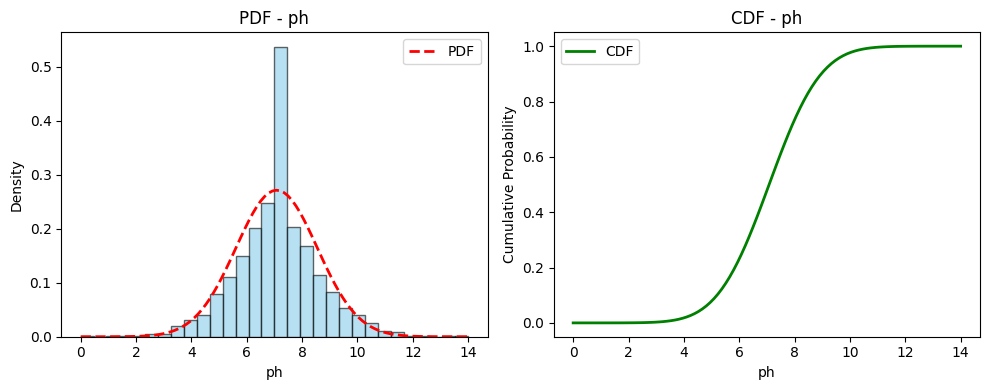

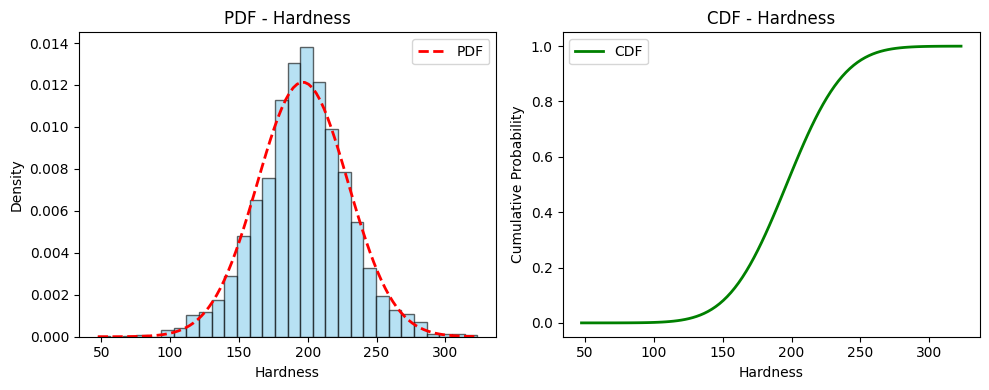

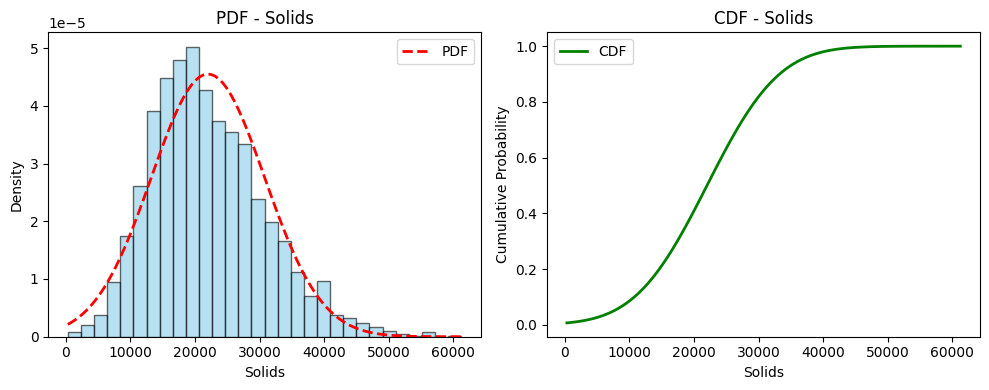

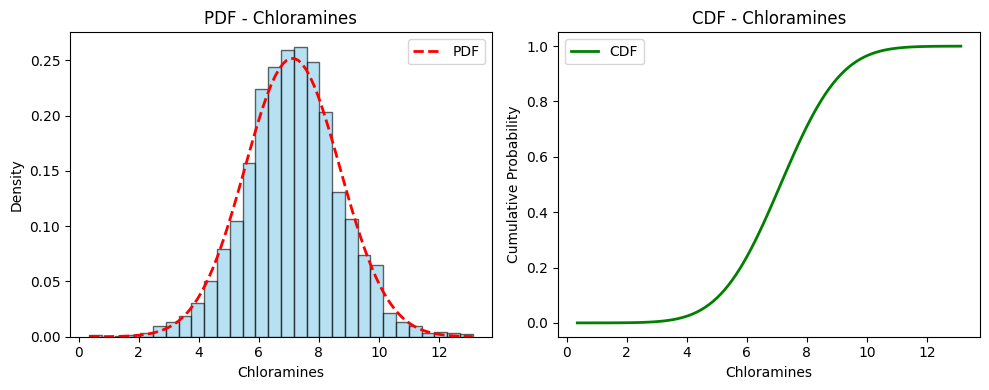

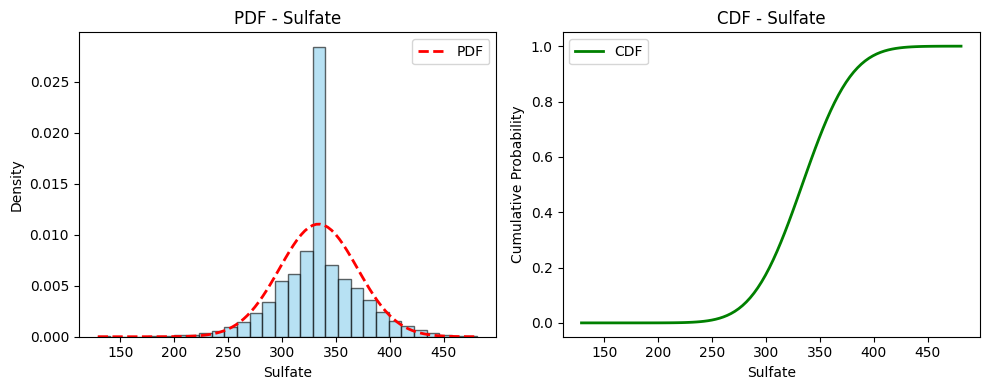

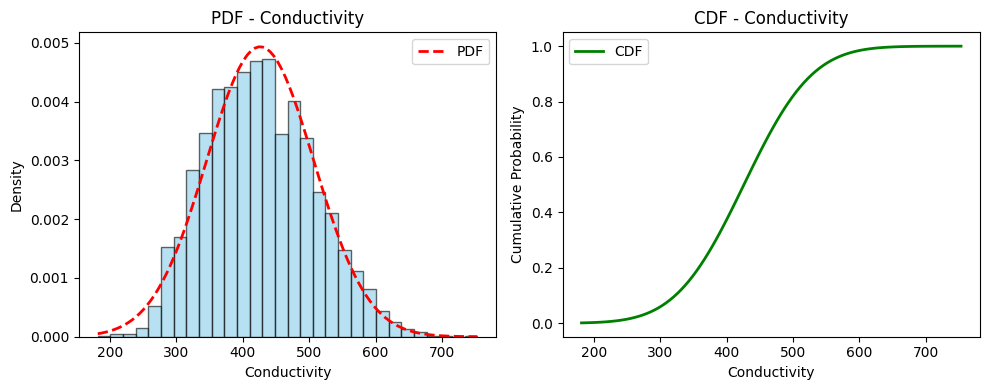

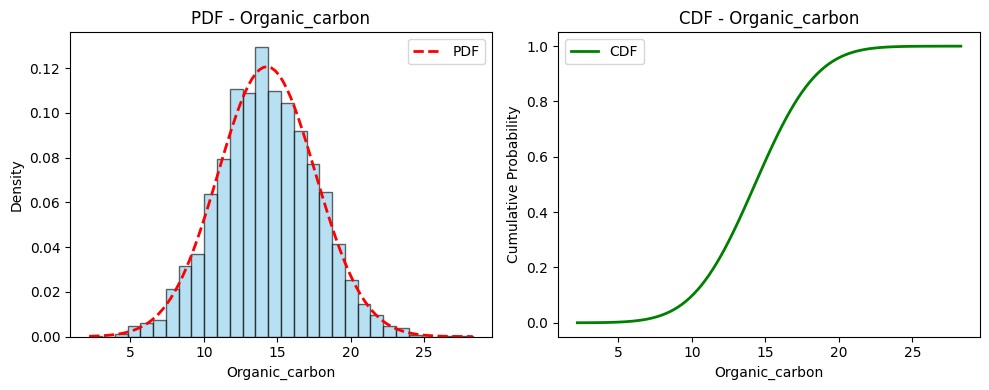

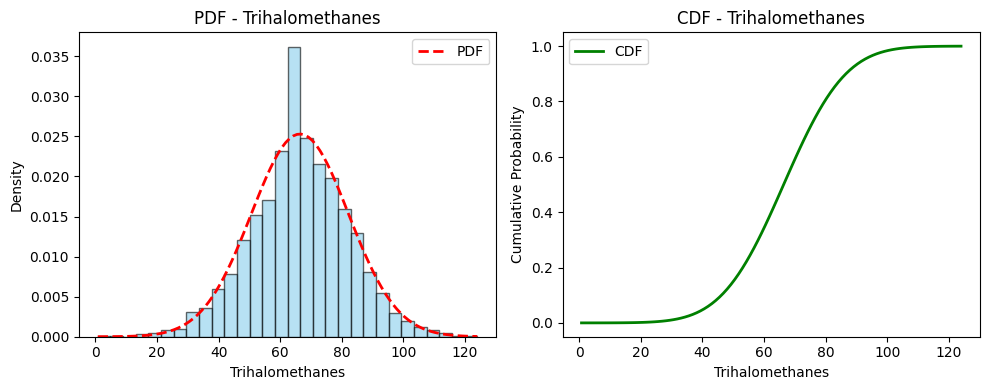

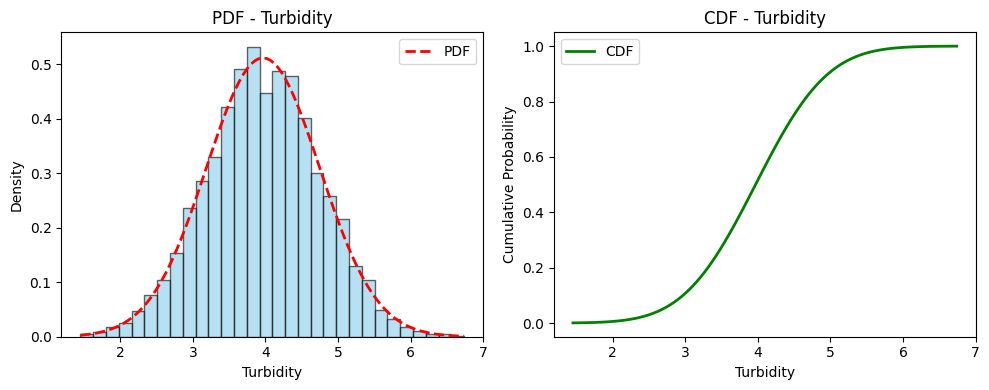

In [9]:
for col in df.columns:
    data = df[col]

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)

    pdf = norm.pdf(x, mu, sigma)
    cdf = norm.cdf(x, mu, sigma)

    plt.figure(figsize=(10, 4))

    # PDF
    plt.subplot(1, 2, 1)
    plt.hist(data, bins=30, density=True, alpha=0.6, color="skyblue", edgecolor="black")
    plt.plot(x, pdf, "r--", linewidth=2, label="PDF")
    plt.title(f"PDF - {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()

    # CDF
    plt.subplot(1, 2, 2)
    plt.plot(x, cdf, "g-", linewidth=2, label="CDF")
    plt.title(f"CDF - {col}")
    plt.xlabel(col)
    plt.ylabel("Cumulative Probability")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [10]:
skew_values = df.skew()
print("Skewness:\n", skew_values)

Skewness:
 ph                 0.027796
Hardness          -0.039342
Solids             0.621634
Chloramines       -0.012098
Sulfate           -0.041184
Conductivity       0.264490
Organic_carbon     0.025533
Trihalomethanes   -0.085161
Turbidity         -0.007817
dtype: float64


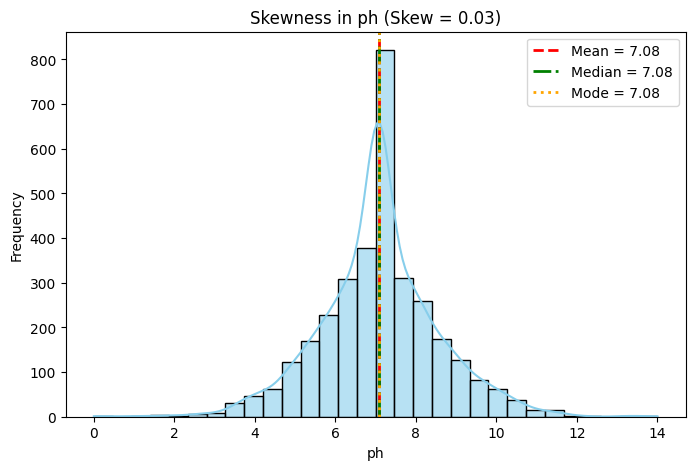

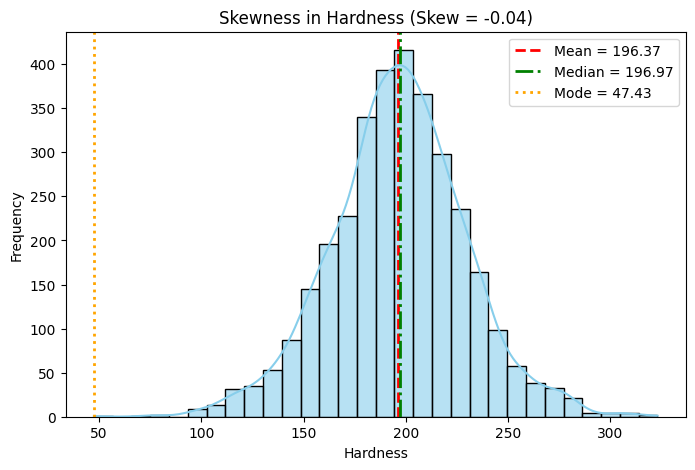

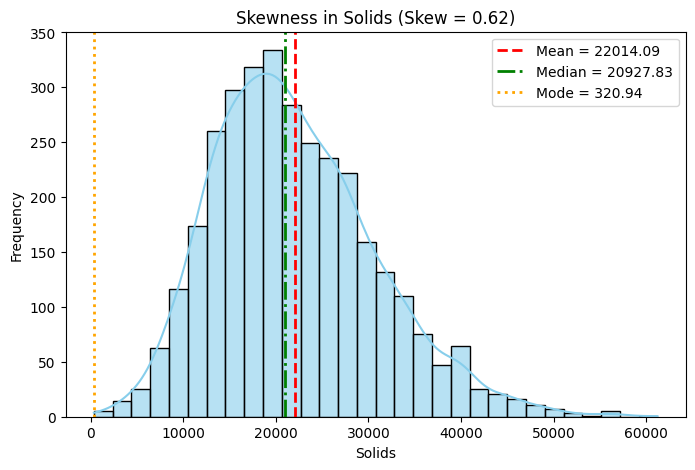

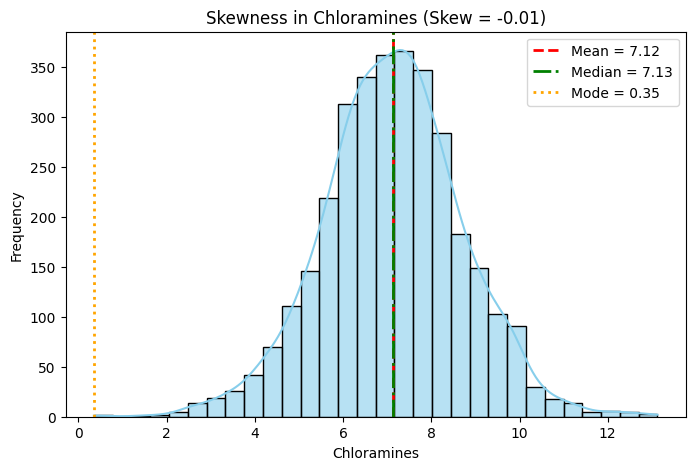

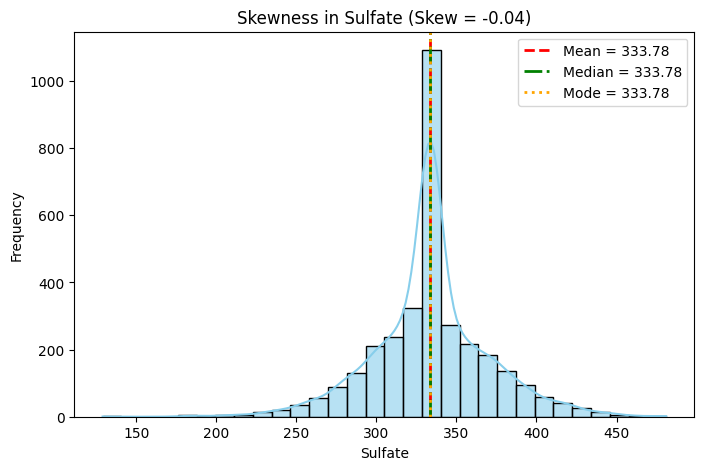

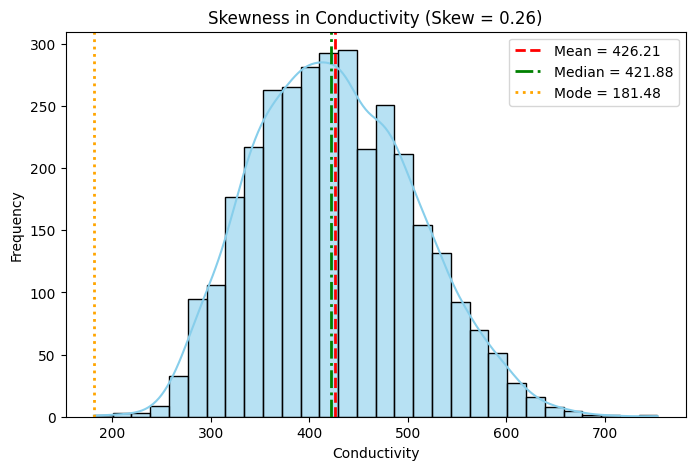

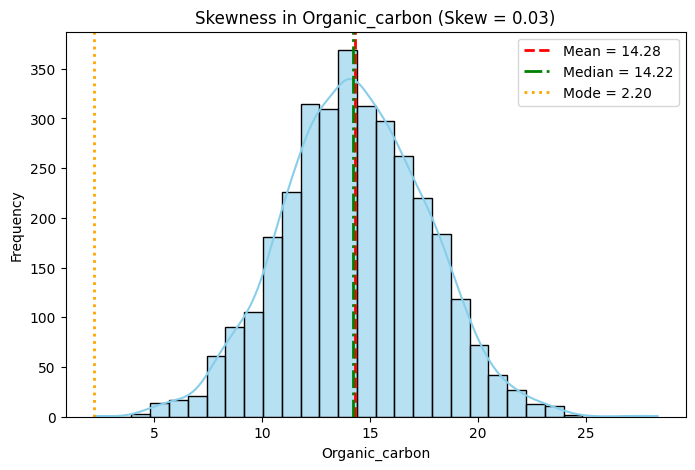

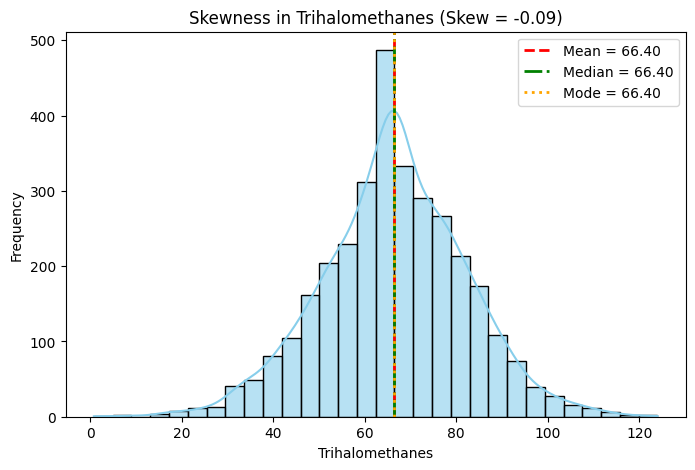

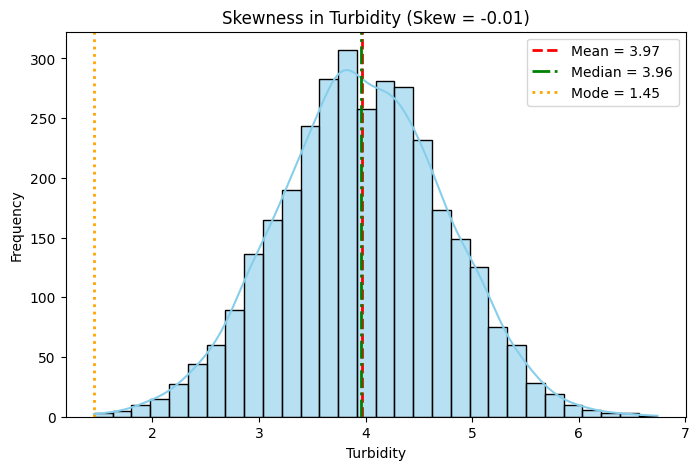

In [11]:
import seaborn as sns

for col in df.columns:
    data = df[col].dropna()  # remove NaN values
    mean = data.mean()
    median = data.median()
    mode = data.mode()[0]
    skew = data.skew()

    plt.figure(figsize=(8, 5))
    sns.histplot(data, bins=30, kde=True, color="skyblue", edgecolor="black", alpha=0.6)

    # Add vertical lines for mean, median, mode
    plt.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean:.2f}")
    plt.axvline(median, color="green", linestyle="-.", linewidth=2, label=f"Median = {median:.2f}")
    plt.axvline(mode, color="orange", linestyle=":", linewidth=2, label=f"Mode = {mode:.2f}")

    plt.title(f"Skewness in {col} (Skew = {skew:.2f})")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


In [12]:
kurt_values = df.kurt()
print("Kurtosis:\n", kurt_values)

Kurtosis:
 ph                 1.376090
Hardness           0.615772
Solids             0.442826
Chloramines        0.589901
Sulfate            1.789965
Conductivity      -0.277093
Organic_carbon     0.044409
Trihalomethanes    0.407102
Turbidity         -0.062801
dtype: float64


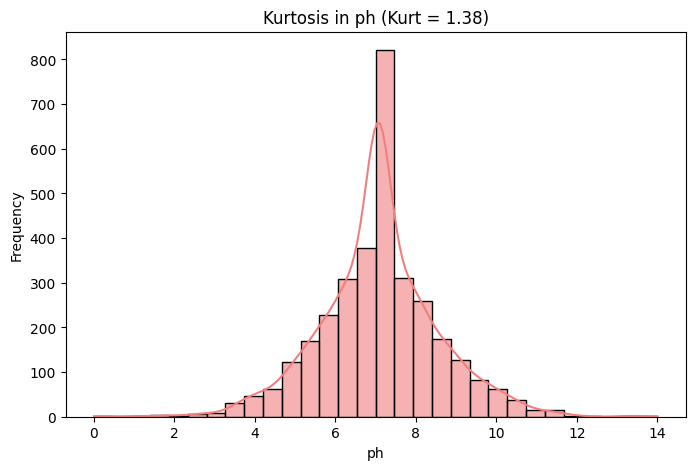

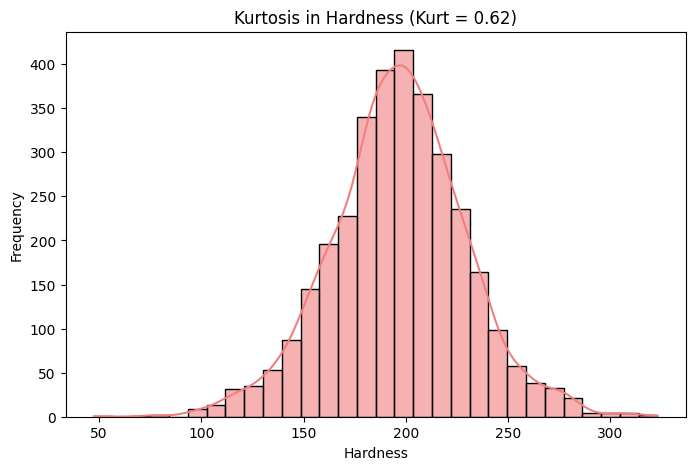

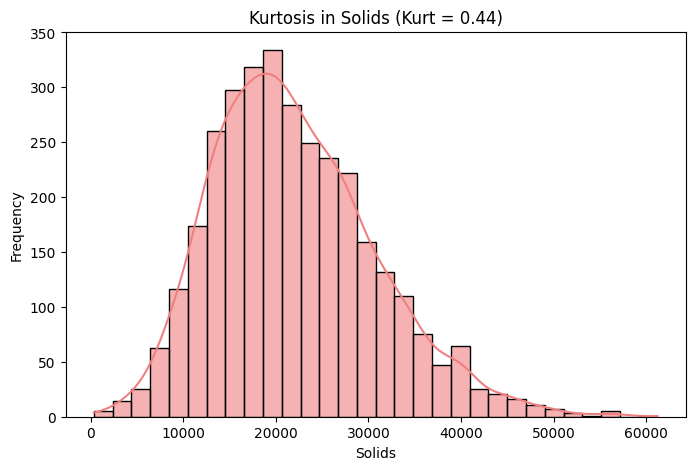

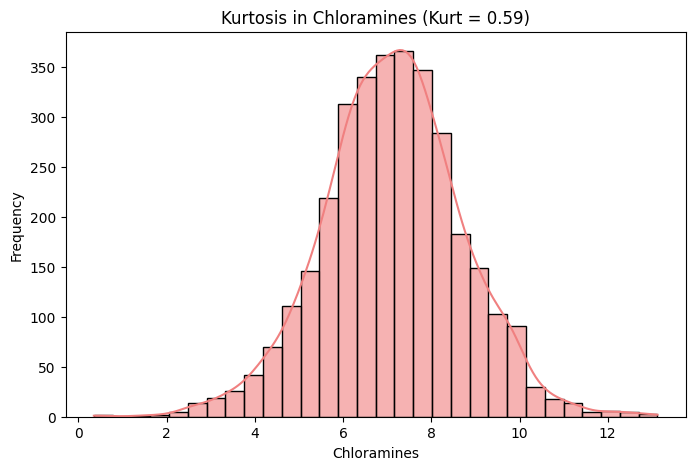

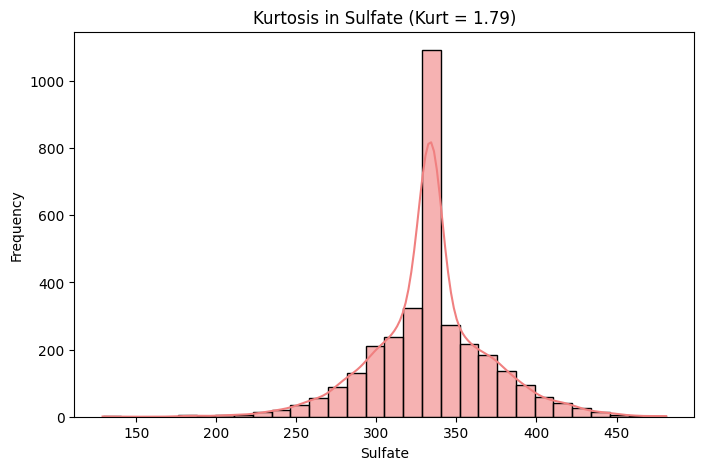

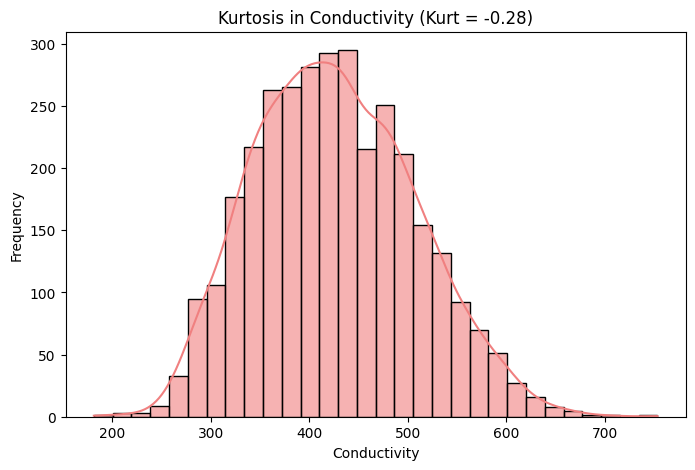

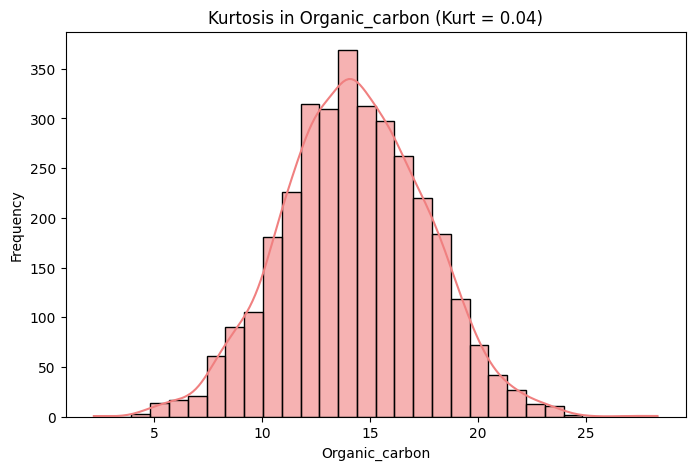

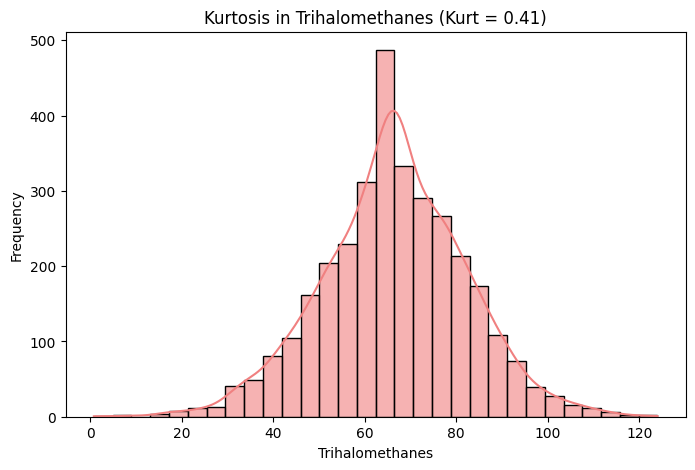

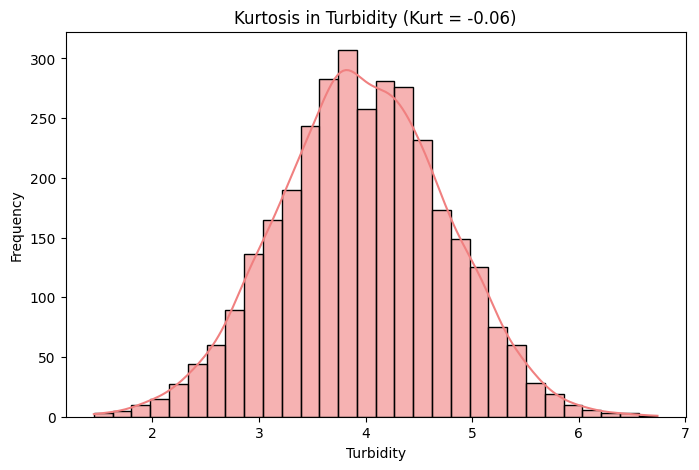

In [13]:
for col in df.columns:
    data = df[col].dropna()  # remove NaN values
    kurt = data.kurt()

    plt.figure(figsize=(8, 5))
    sns.histplot(data, bins=30, kde=True, color="lightcoral", edgecolor="black", alpha=0.6)

    plt.title(f"Kurtosis in {col} (Kurt = {kurt:.2f})")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [14]:
pearson_skewness = 3 * (mean_values - median_values) / std_values
print("Pearson's Skewness:\n", pearson_skewness)

Pearson's Skewness:
 ph                 1.812663e-15
Hardness          -5.457438e-02
Solids             3.716429e-01
Chloramines       -1.520231e-02
Sulfate           -9.436521e-15
Conductivity       1.603536e-01
Organic_carbon     6.042538e-02
Trihalomethanes    0.000000e+00
Turbidity          4.520325e-02
dtype: float64


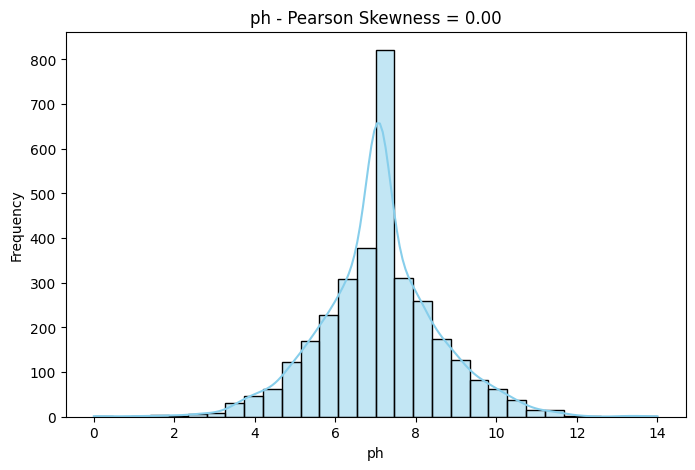

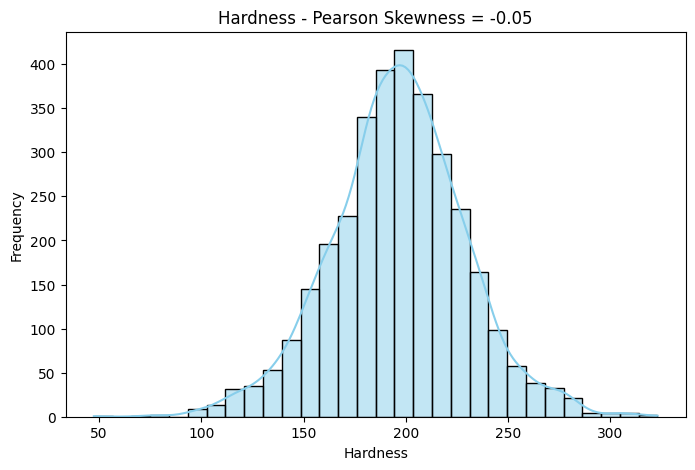

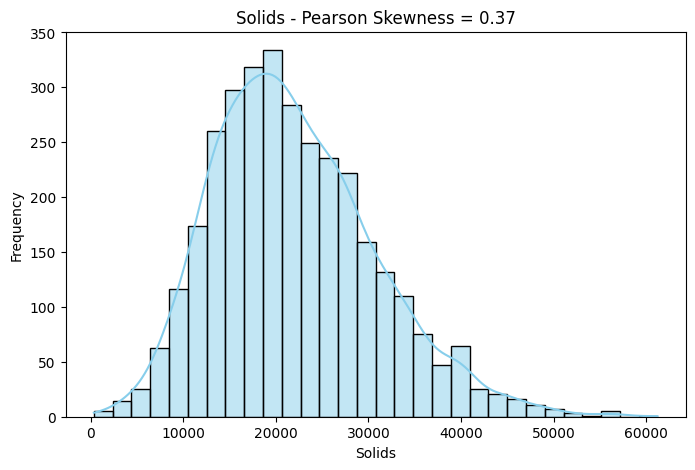

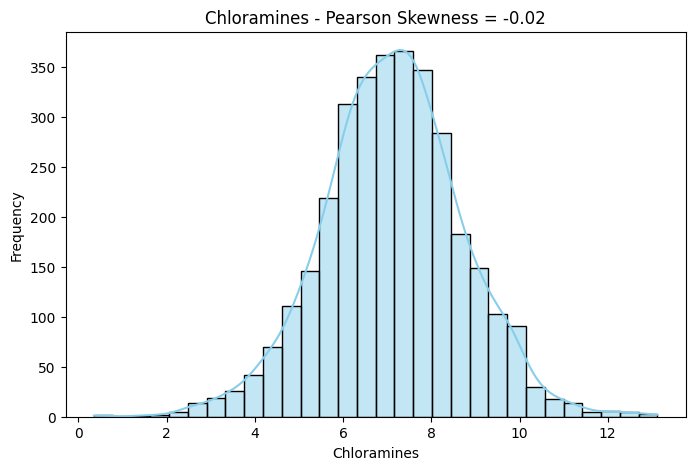

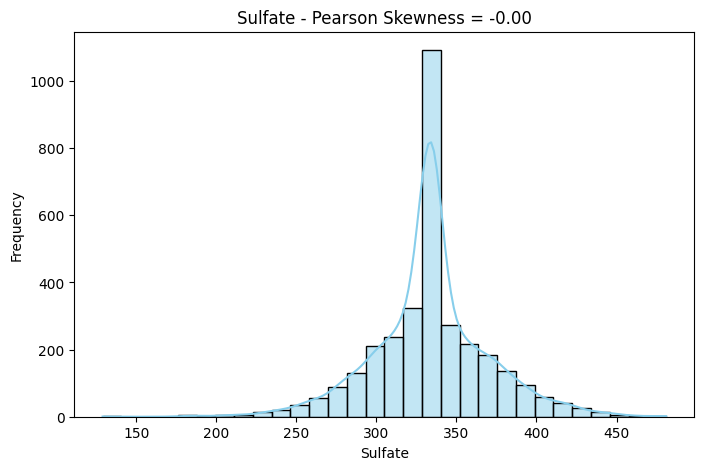

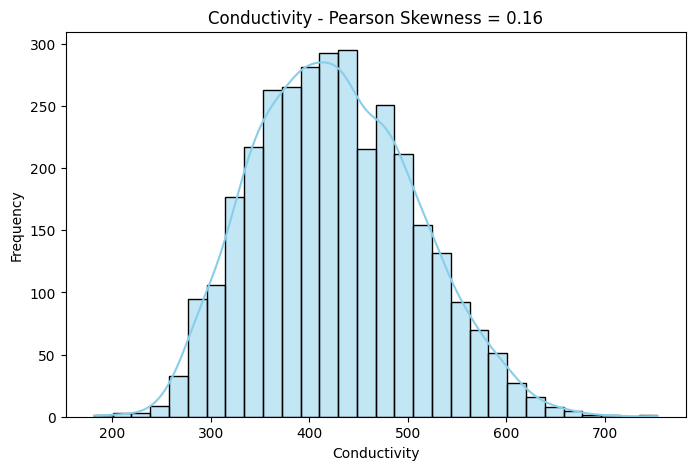

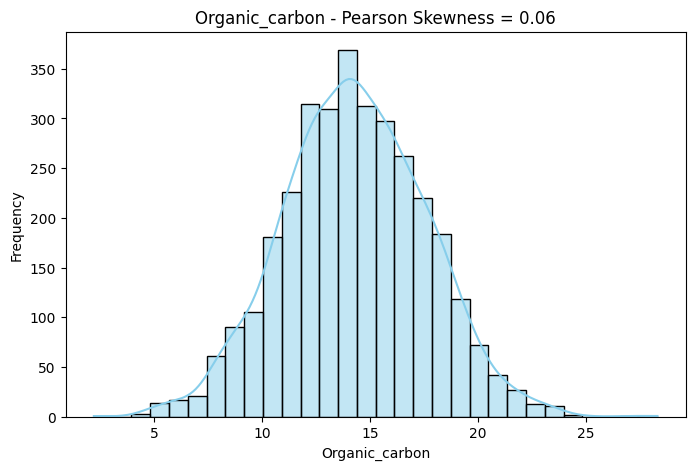

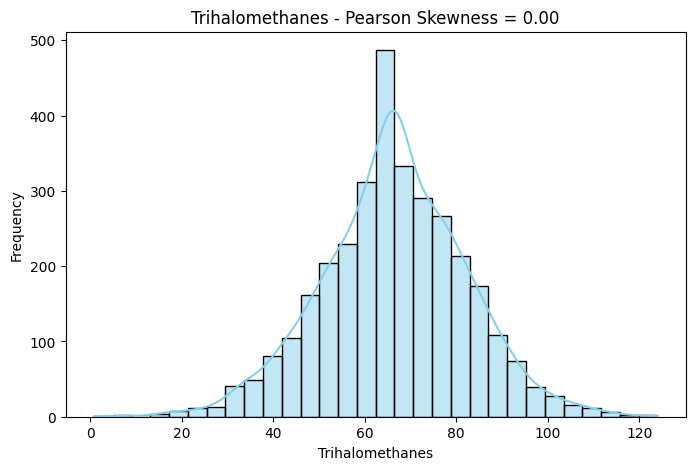

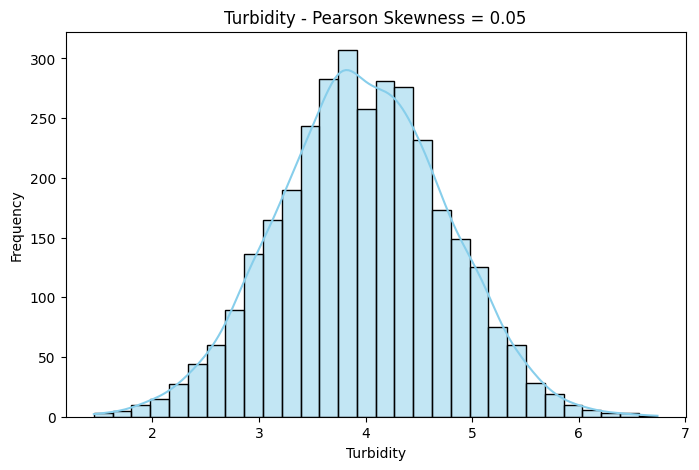

In [15]:
for col in df.columns:
    data = df[col].dropna()
    skew_p = pearson_skewness[col]
    
    plt.figure(figsize=(8,5))
    sns.histplot(data, bins=30, kde=True, color="skyblue", edgecolor="black")
    
    plt.title(f"{col} - Pearson Skewness = {skew_p:.2f}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

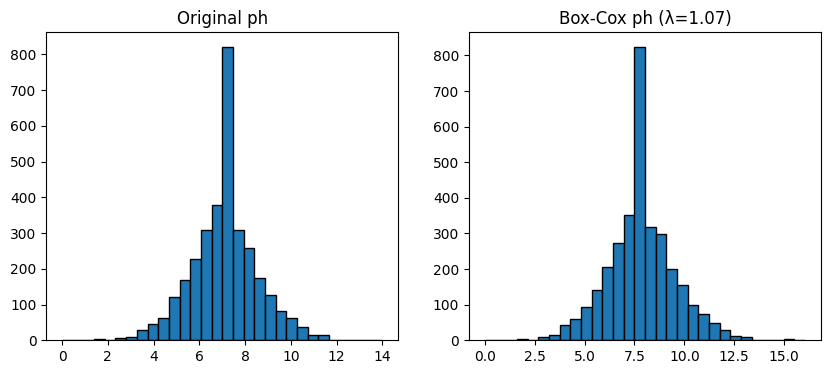

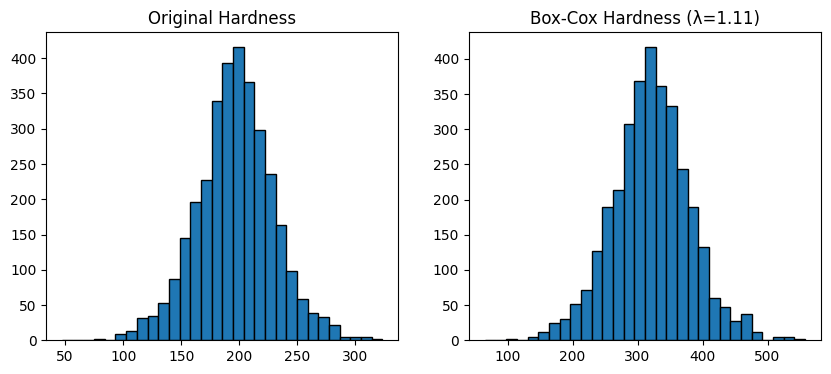

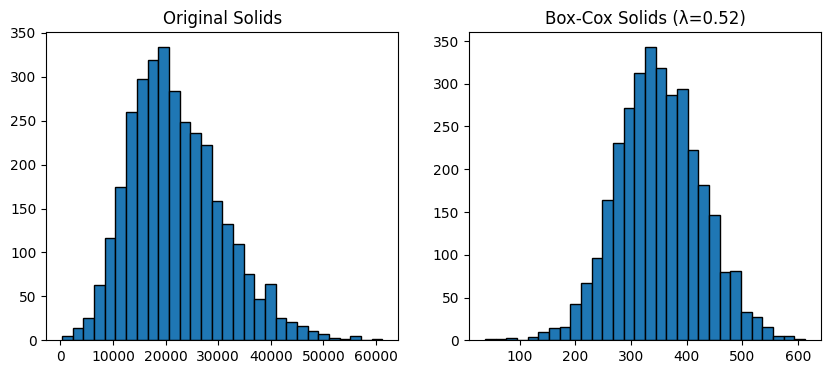

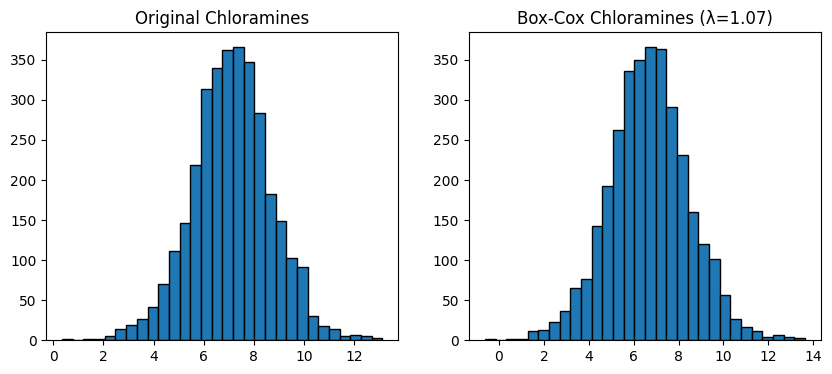

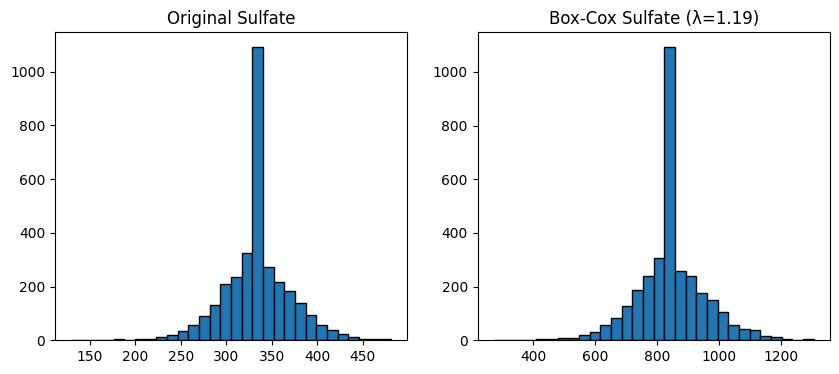

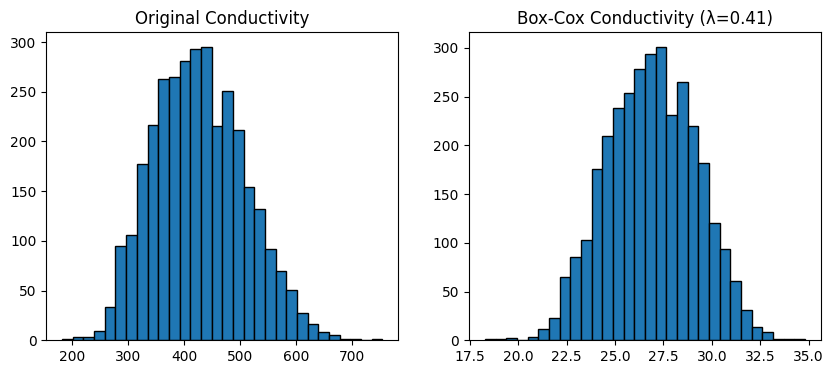

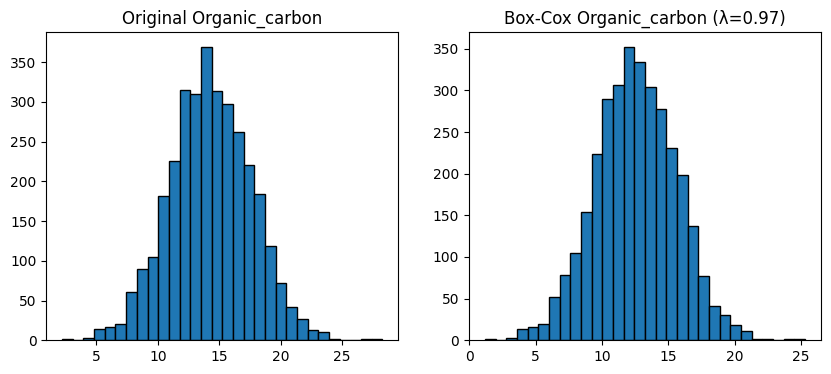

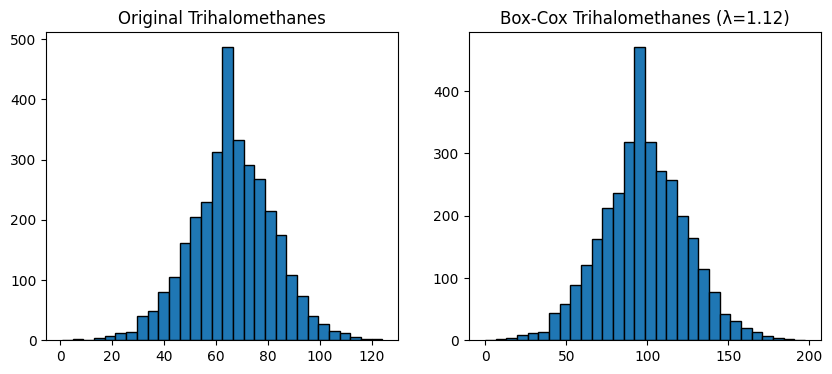

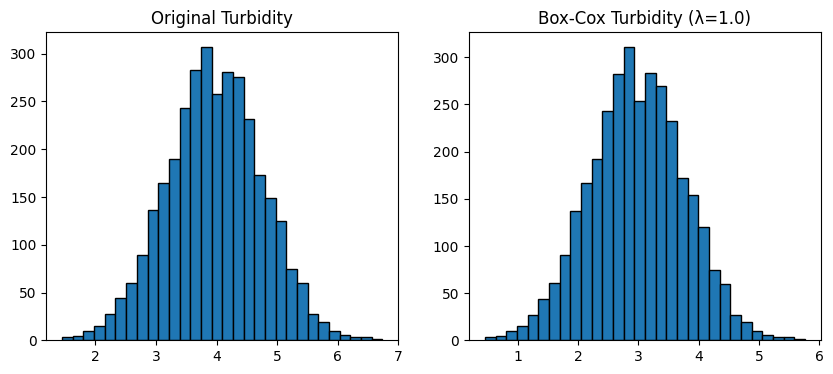

ph -> Optimal λ = 1.071
Hardness -> Optimal λ = 1.113
Solids -> Optimal λ = 0.524
Chloramines -> Optimal λ = 1.065
Sulfate -> Optimal λ = 1.190
Conductivity -> Optimal λ = 0.412
Organic_carbon -> Optimal λ = 0.969
Trihalomethanes -> Optimal λ = 1.121
Turbidity -> Optimal λ = 1.004


In [16]:
from scipy.stats import boxcox
boxcox_results = {}

for col in df.columns:
    data = df[col].values
    
    # Box-Cox requires strictly positive values
    if (data <= 0).any():
        # Shift data by +1 (or a small constant) if zeros or negatives exist
        data = data + 1
    
    # Apply Box-Cox
    transformed, lambda_opt = boxcox(data)
    
    # Store results
    boxcox_results[col] = {
        "lambda": lambda_opt,
        "transformed": transformed
    }
    
    # Plot before and after transformation
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f"Original {col}")
    
    plt.subplot(1,2,2)
    plt.hist(transformed, bins=30, edgecolor='black')
    plt.title(f"Box-Cox {col} (λ={round(lambda_opt,2)})")
    
    plt.show()

# Print optimal λ values
for feature, result in boxcox_results.items():
    print(f"{feature} -> Optimal λ = {result['lambda']:.3f}")